In [3]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

conn = sqlite3.connect("imgw.db")

# Balanced panel: only stations reporting in every year, so year-to-year
# averages compare the same stations and aren't skewed by the shrinking network.
PANEL = """station_code IN (
    SELECT station_code FROM measurements_clean
    GROUP BY station_code
    HAVING COUNT(DISTINCT strftime('%Y', date)) =
           (SELECT COUNT(DISTINCT strftime('%Y', date)) FROM measurements_clean)
)"""

n_panel = pd.read_sql(
    f"SELECT COUNT(DISTINCT station_code) AS n FROM measurements_clean WHERE {PANEL}",
    conn)["n"][0]
print(f"Balanced panel: {n_panel} stations present in all years")

df = pd.read_sql(f"SELECT date, tmean FROM measurements_clean WHERE {PANEL}",
                 conn, parse_dates=["date"]).set_index("date").sort_index()


Balanced panel: 34 stations present in all years


# Heatmap

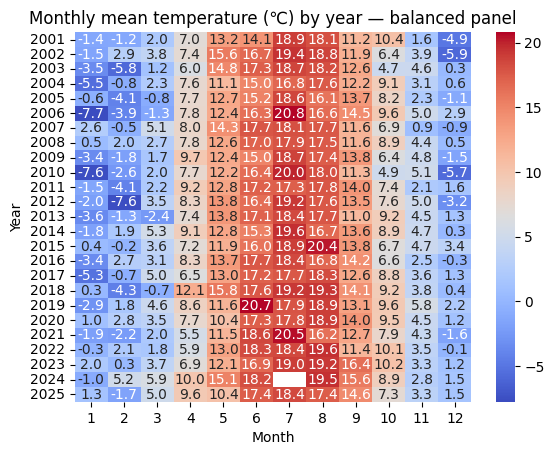

Minimum temperature: -7.7°C — 2006-01
Maximum temperature: 20.8°C — 2006-07


In [4]:
# HEATMAP — monthly mean tmean per year (balanced panel)
heatmap = pd.read_sql(f"""
    SELECT CAST(strftime('%Y', date) AS INT) AS year,
           CAST(strftime('%m', date) AS INT) AS month,
           AVG(tmean) AS tmean
    FROM measurements_clean
    WHERE {PANEL}
    GROUP BY year, month
""", conn)
df_heatmap_grouped = heatmap.pivot(index="year", columns="month", values="tmean")

sns.heatmap(df_heatmap_grouped, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Monthly mean temperature (℃) by year — balanced panel')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

tmin = df_heatmap_grouped.min().min()
tmax = df_heatmap_grouped.max().max()
min_month = df_heatmap_grouped.min(axis=0).idxmin()
min_year = df_heatmap_grouped[min_month].idxmin()
max_month = df_heatmap_grouped.max(axis=0).idxmax()
max_year = df_heatmap_grouped[max_month].idxmax()
print(f'Minimum temperature: {tmin:.1f}°C — {min_year}-{min_month:02d}')
print(f'Maximum temperature: {tmax:.1f}°C — {max_year}-{max_month:02d}')

# Heatmap Analysis
- The heatmap is dominated by the seasonal cycle; year-to-year warming is subtle
  and noisy at monthly resolution, so the robust trend evidence comes from the
  per-station regression below, not from eyeballing this grid.
- Both extremes fall in 2006: a severe January cold spell and a July heatwave.
- Coldest month: January 2006 (−7.7°C)
- Hottest month: July 2006 (20.8°C)
- Note: July 2024 is blank — no panel station has data for that month (data gap).


# Boxplot

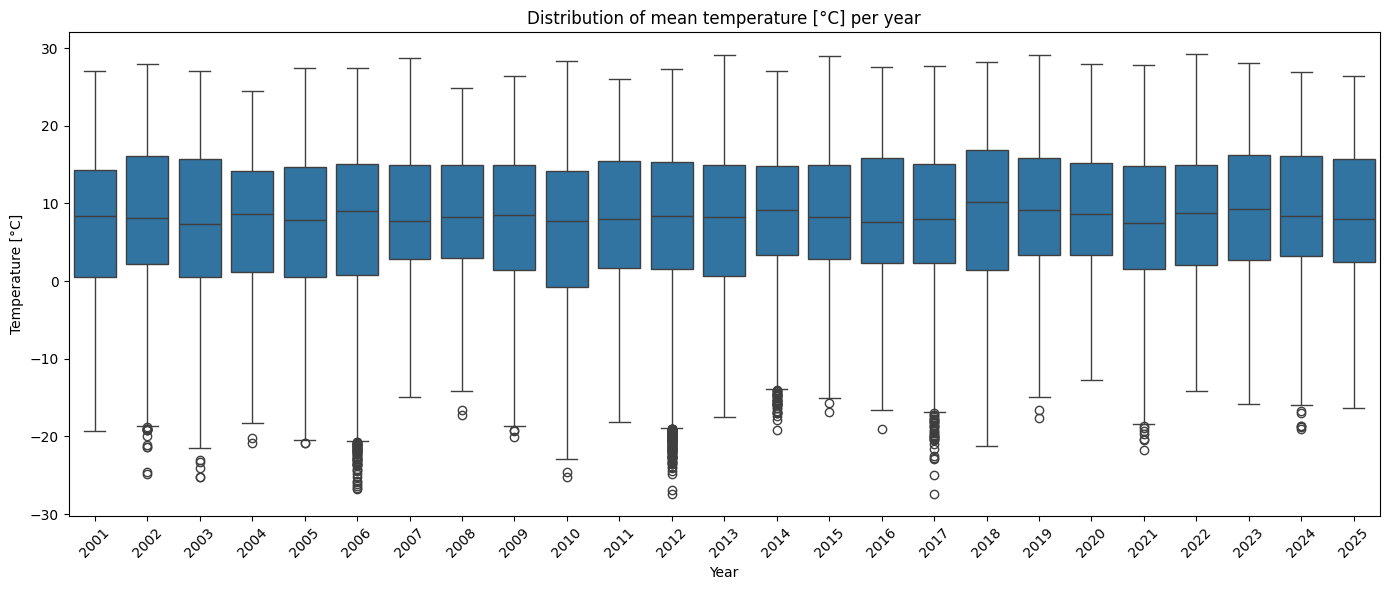

Warmest year by median: 2018 (10.2°C)
Coolest years by median:
  2003: 7.4°C
  2021: 7.5°C


In [5]:
#Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(x=df.index.year, y=df['tmean'])
plt.title('Distribution of mean temperature [°C] per year')
plt.xlabel('Year')
plt.ylabel('Temperature [°C]')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
medians = df.groupby(df.index.year)['tmean'].median()
print(f"Warmest year by median: {medians.idxmax()} ({medians.max():.1f}°C)")
print("Coolest years by median:")
for year, val in medians.nsmallest(2).items():
    print(f"  {year}: {val:.1f}°C")

# Boxplot Analysis
- On the balanced panel the yearly medians stay ~7–10°C with no visible upward
  trend — the apparent warming in the all-station version was largely a
  composition artifact (colder stations dropping out of the network over time).
- Warmest year by median: 2018 (10.2°C); coolest: 2003 (7.4°C) and 2021 (7.5°C).
- The within-year spread is huge (winter days near −20°C, summer near +30°C),
  so each box's IQR dwarfs the ~1°C of warming expected over 25 years. A yearly
  boxplot of daily means simply can't resolve a trend this small.
- Robust trend evidence therefore comes from the per-station regression below,
  which isolates each station's own slope instead of averaging across a mix.

# Correlation 

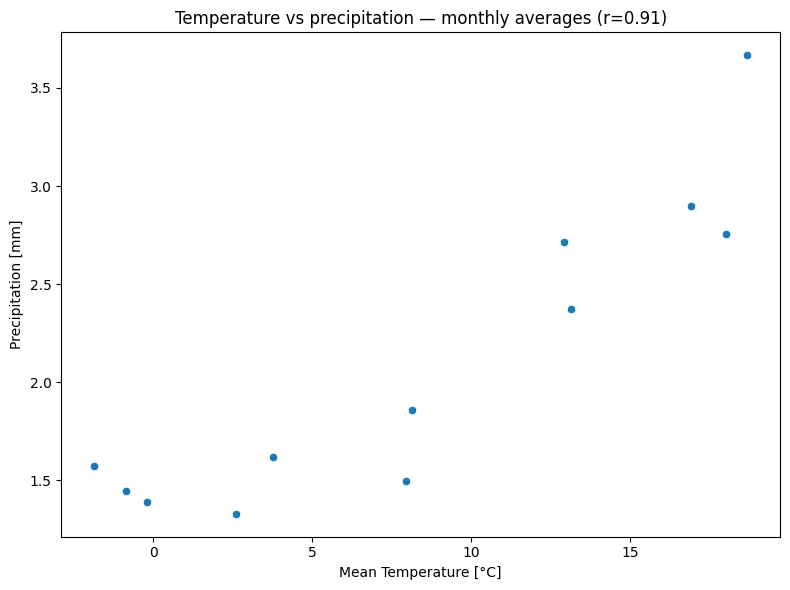

Pearson correlation coefficient: 0.91, p-value: 0.0000
Coldest month:  month 1, -1.9°C, 1.57 mm
Warmest month:  month 7, 18.7°C, 3.67 mm
Driest month:   month 3, 2.6°C, 1.33 mm


In [6]:
# scatterplot — temp vs precipitation, monthly averages (balanced panel)
monthly = pd.read_sql(f"""
    SELECT CAST(strftime('%m', date) AS INT) AS month,
           AVG(tmean)         AS tmean,
           AVG(precipitation) AS precipitation
    FROM measurements_clean
    WHERE {PANEL}
    GROUP BY month
    ORDER BY month
""", conn)

r, p = pearsonr(monthly['tmean'], monthly['precipitation'])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='tmean', y='precipitation', data=monthly)
plt.title(f'Temperature vs precipitation — monthly averages (r={r:.2f})')
plt.xlabel('Mean Temperature [°C]')
plt.ylabel('Precipitation [mm]')
plt.tight_layout()
plt.show()

print(f'Pearson correlation coefficient: {r:.2f}, p-value: {p:.4f}')
cold = monthly.loc[monthly['tmean'].idxmin()]
warm = monthly.loc[monthly['tmean'].idxmax()]
dry = monthly.loc[monthly['precipitation'].idxmin()]
print(f"Coldest month:  month {int(cold['month'])}, {cold['tmean']:.1f}°C, {cold['precipitation']:.2f} mm")
print(f"Warmest month:  month {int(warm['month'])}, {warm['tmean']:.1f}°C, {warm['precipitation']:.2f} mm")
print(f"Driest month:   month {int(dry['month'])}, {dry['tmean']:.1f}°C, {dry['precipitation']:.2f} mm")

# Correlation Analysis
- Each dot is one calendar month averaged over ~25 years (n = 12 points), balanced panel.
- Strong positive correlation (r = 0.91, p < 0.0001): warmer months are wetter.
- This reflects Poland's seasonal cycle — summer convective rainfall — rather than
  a causal temperature→precipitation link.
- Coldest month (January, −1.9°C) averages ~1.6 mm/day; warmest (July, 18.7°C)
  reaches ~3.7 mm/day.
- The coldest month isn't the driest: January still gets ~1.6 mm from winter snow,
  while March is the driest at 1.33 mm — the low point of the seasonal cycle.
- Caveat: the 12 points trace the seasonal cycle and are autocorrelated, not independent
  samples — treat the p-value as descriptive, not a strict significance test.

# Temperature Trend

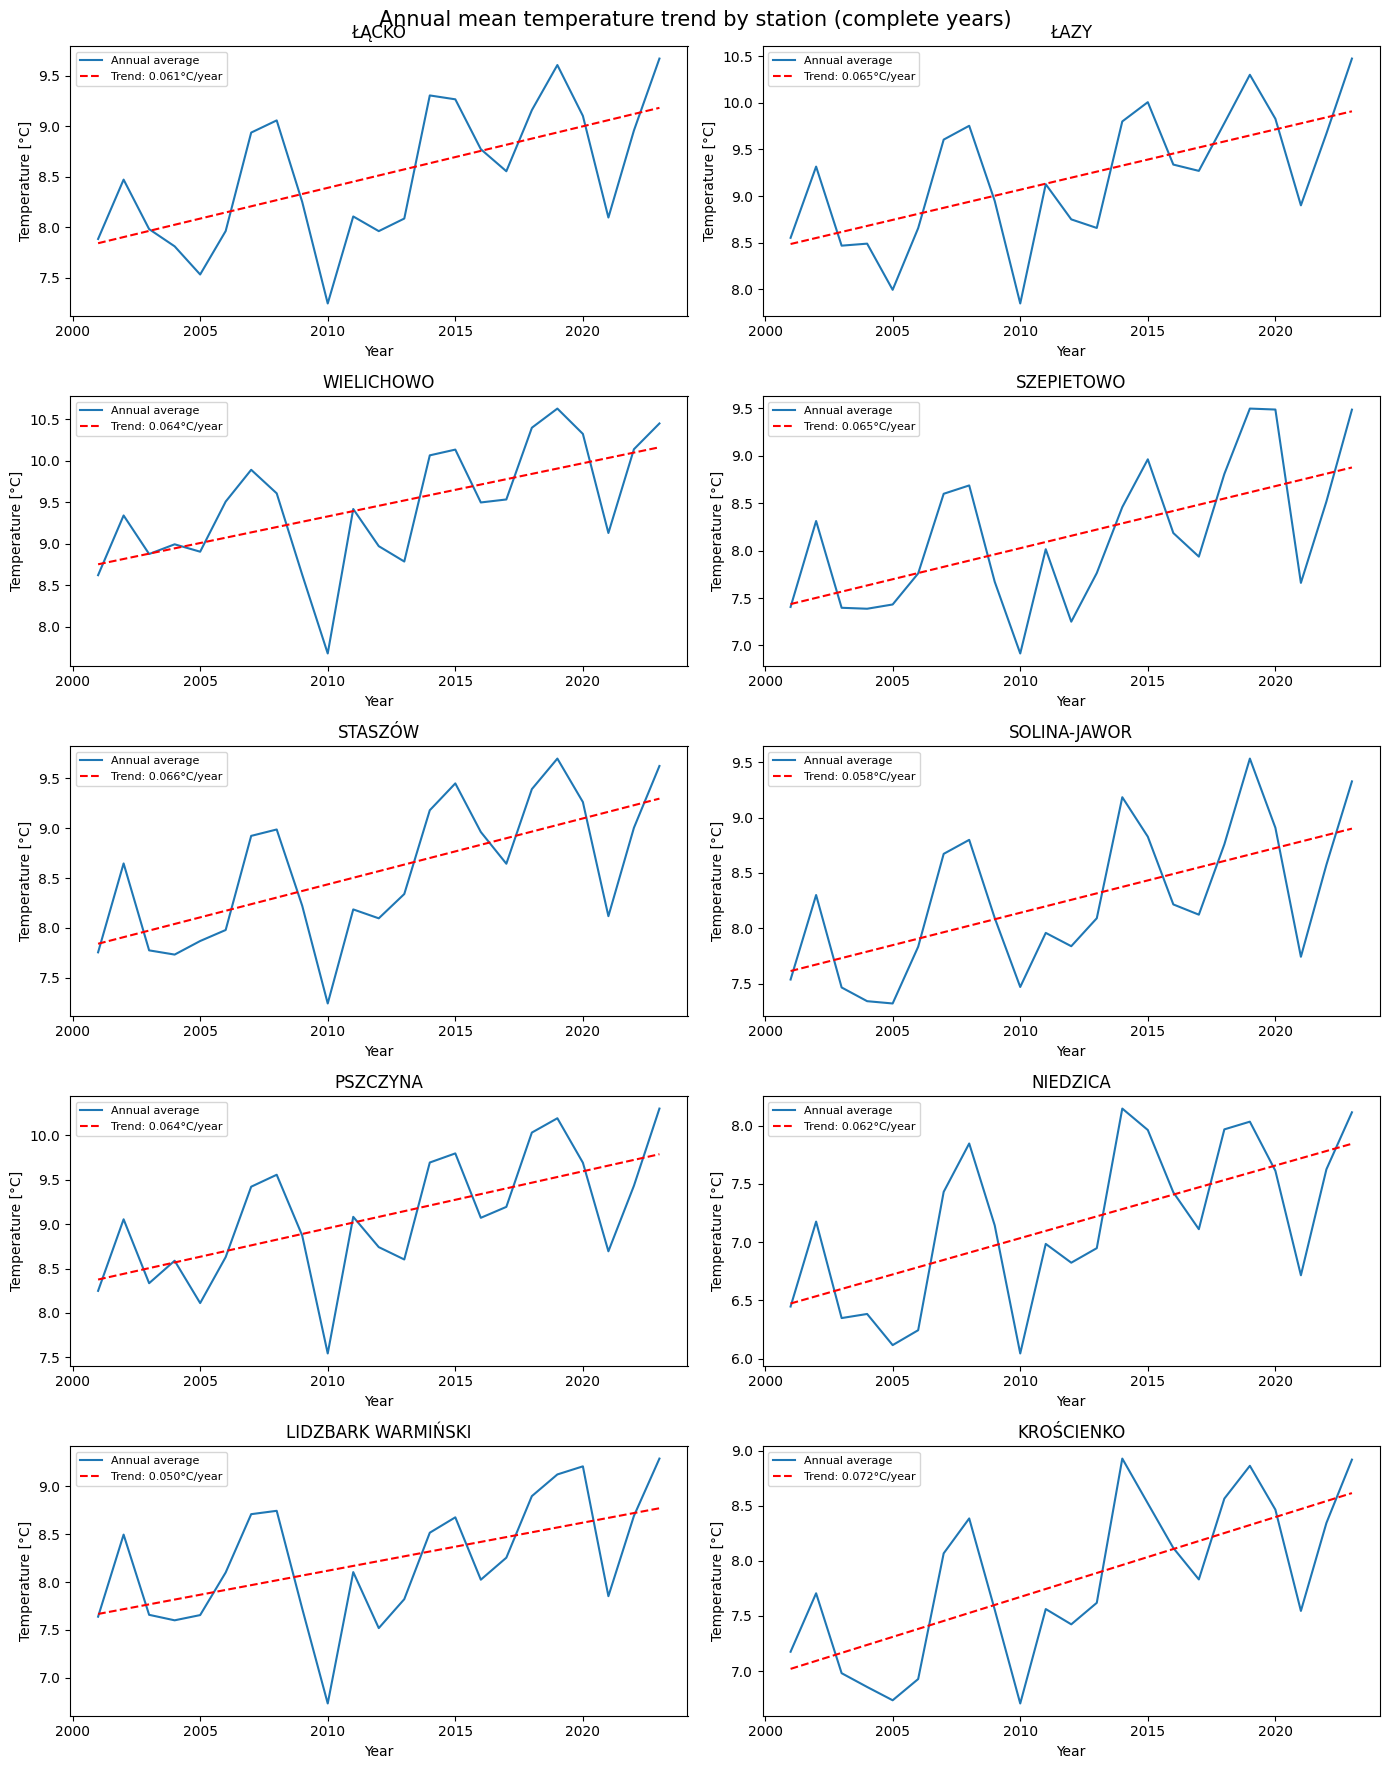

Warming trend by station (°C/year), fastest first:
  KROŚCIENKO           +0.072
  STASZÓW              +0.066
  SZEPIETOWO           +0.065
  ŁAZY                 +0.065
  PSZCZYNA             +0.064
  WIELICHOWO           +0.064
  NIEDZICA             +0.062
  ŁĄCKO                +0.061
  SOLINA-JAWOR         +0.058
  LIDZBARK WARMIŃSKI   +0.050


In [7]:
# Linear trend per station — top 10 by record count, complete years only.
top10 = pd.read_sql(f"""
    SELECT station_name
    FROM measurements_clean
    WHERE {PANEL}
    GROUP BY station_name
    ORDER BY COUNT(*) DESC
    LIMIT 10
""", conn)['station_name'].tolist()

yearly_all = pd.read_sql(f"""
    SELECT station_name,
           CAST(strftime('%Y', date) AS INT) AS year,
           AVG(tmean) AS tmean
    FROM measurements_clean
    WHERE {PANEL}
    GROUP BY station_name, year
    HAVING COUNT(DISTINCT strftime('%m', date)) = 12
    ORDER BY station_name, year
""", conn)

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
slopes = {}
for ax, station in zip(axes.flat, top10):
    yearly = yearly_all[yearly_all['station_name'] == station]
    slope, intercept = np.polyfit(yearly['year'], yearly['tmean'], 1)
    slopes[station] = slope

    ax.plot(yearly['year'], yearly['tmean'], label='Annual average')
    ax.plot(yearly['year'], np.poly1d([slope, intercept])(yearly['year']), '--',
            color='red', label=f'Trend: {slope:.3f}°C/year')
    ax.set_title(station)
    ax.set_xlabel('Year')
    ax.set_ylabel('Temperature [°C]')
    ax.legend(fontsize=8)

for ax in axes.flat[len(top10):]:
    ax.set_visible(False)

fig.suptitle('Annual mean temperature trend by station (complete years)', fontsize=15)
plt.tight_layout()
plt.show()

print('Warming trend by station (°C/year), fastest first:')
for station, slope in sorted(slopes.items(), key=lambda kv: kv[1], reverse=True):
    print(f'  {station:<20} {slope:+.3f}')

# Temperature Trend Analysis
- Annual mean temperature per station, complete years only (2001–2023), so a
  partial final year can't drag the regression down.
- All 10 stations warm, +0.050 to +0.072°C/year — roughly +1.1 to +1.6°C over
  the 23-year period.
- This ~0.6°C/decade rate matches IMGW's reported warming for Poland, which runs
  faster than the global mean.
- Warming is broad, not local: fastest at Krościenko (+0.072) and Staszów
  (+0.066), slowest at Lidzbark Warmiński (+0.050) — but every slope is positive.
- Caveat: an OLS slope over 23 annual points is sensitive to the endpoints
  (2001 was relatively cool, recent years hot), so the exact rate should be read
  as approximate rather than a precise per-year figure.
- This per-station view is the notebook's primary trend evidence. Because each
  station is fit on its own record, the result is immune to the changing-network
  artifact that inflated the raw heatmap and boxplot, and to the partial-year
  dip that suppressed the earlier all-years version.